In [1]:
import pandas as pd

# Importamos la función train_test_split de sklearn.model_selection
# para dividir nuestros datos en conjuntos de entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Importamos el StandardScaler para normalizar los datos.
from sklearn.preprocessing import StandardScaler

# Importamos el clasificador KNN de sklearn.neighbors
# para la clasificación y la regresión
from sklearn.neighbors import KNeighborsClassifier

# Importamos las funciones classification_report y confusion_matrix
# de sklearn.metrics para evaluar la precisión del modelo y
# para visualizar los resultados de la clasificación
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

from matplotlib import pyplot as plt

from sklearn.tree import DecisionTreeClassifier #arbol de clasificación
from sklearn.model_selection import train_test_split #funcion para dividir datos en train y test
from sklearn.metrics import make_scorer, accuracy_score, recall_score, confusion_matrix
from sklearn.tree import plot_tree
import numpy as np
import seaborn as sns

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

from google.colab import drive
drive.mount('/content/drive')

ruta = "/content/drive/MyDrive/Ciencia de datos/Datos TPI 2026/"

data_clientes = pd.read_excel(ruta + "dataset_K_Means.xlsx")

# Limpiar nombres de columnas
data_clientes.columns = data_clientes.columns.str.strip()

cluster_labels = data_clientes['cluster_kmeans'].values  # ← agregar ANTES del drop

data_clientes.drop(
    columns=[
        'id_cliente',
        'ocupacion',
        'sexo',
        'canal_compra',
        'pais_origen',
        'cluster_kmeans',   # ← ahora sí se puede eliminar
    ],
    inplace=True
)

# Variables categóricas
data_clientes['programaMillas'] = data_clientes['programaMillas'].map({
    'Sí': 1,
    'No': 0
})

data_clientes['clase_preferida'] = data_clientes['clase_preferida'].map({
    'Económica': 0,
    'Ejecutiva': 1,
    'Primera clase': 2
})

# Verificar nulos
print(data_clientes.isnull().sum())

# Escalado
scaler = StandardScaler()
df_scaled = scaler.fit_transform(data_clientes)

print(df_scaled.shape)

Mounted at /content/drive
edad                            0
cant_vuelos                     0
clase_preferida                 0
gasto_acumulado                 0
gasto_acumulado_extra           0
programaMillas                  0
cantidad_millas                 0
ingreso_mensual                 0
anticipacion_compra_promedio    0
dtype: int64
(5466, 9)


In [3]:
from sklearn.decomposition import PCA

pca = PCA(n_components=9)

# Ajustamos el modelo a los datos.
pca.fit(df_scaled)

# Transformamos los datos.
df_pca = pca.transform(df_scaled)

# Convertimos los datos transformados en un DataFrame de Pandas.
df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2','PC3', 'PC4','PC5', 'PC6','PC7', 'PC8','PC9'])

# Mostramos las primeras filas del DataFrame.
df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,-0.306507,-0.547293,0.619818,0.975346,0.130791,1.012085,0.107851,-0.472899,-0.049598
1,2.224053,-1.747006,0.174589,-0.870173,2.192462,1.934313,-0.319573,-0.314240,0.446108
2,3.424237,0.569824,-0.172804,0.106124,1.636583,-2.148081,0.375309,0.976750,1.068663
3,0.115000,1.831220,-0.719048,-1.571534,0.241816,0.012023,-1.051843,0.080353,0.059674
4,-1.198970,-0.597325,-1.534548,1.891751,-0.099118,0.448817,0.188808,-0.499056,0.020911


In [4]:
loadings = pca.components_.T  # Transponer para alinear con las variables originales en las filas

features = ['X1', 'X2', 'X3','X4', 'X5', 'X6','X7', 'X8', 'X9', ]

# Crear el DataFrame de cargas
loadings_df = pd.DataFrame(loadings, columns=[f'PC{i+1}' for i in range(loadings.shape[1])], index=features)

loadings_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
X1,0.068344,-0.066367,0.713630,0.661494,-0.149329,-0.139714,0.035031,-0.031843,-0.004797
X2,0.382053,0.146016,0.059891,-0.053322,-0.457779,0.511526,-0.076111,0.583245,-0.095375
X3,0.352061,-0.362436,-0.067710,0.037492,0.451472,-0.422022,0.056964,0.585302,-0.104645
X4,0.481394,-0.175418,-0.085739,-0.057808,-0.228490,-0.162764,-0.128455,-0.195278,0.770364
X5,0.455479,-0.190184,-0.106301,-0.068870,-0.278202,-0.204698,-0.250701,-0.418840,-0.618668
X6,0.184237,0.734001,-0.033367,0.147005,0.287713,-0.183086,-0.535305,0.033067,0.025102
X7,0.378824,0.437043,-0.098057,0.053285,0.039739,-0.080421,0.787571,-0.147168,-0.055307
X8,0.321233,-0.189666,0.110803,0.086042,0.583959,0.646162,-0.057152,-0.281679,0.003657
X9,-0.074662,-0.101174,-0.664006,0.719888,-0.096657,0.121706,-0.017245,0.024034,0.003999


In [5]:
df_varianza = pd.DataFrame(data={'Componente': range(1, 10), 'Varianza': pca.explained_variance_})
df_varianza

,Componente,Varianza
0,1,3.525668
1,2,1.225456
2,3,1.051570
3,4,0.939722
4,5,0.834594
5,6,0.623919
6,7,0.378249
7,8,0.328629
8,9,0.093840


In [6]:
df_varianza = pd.DataFrame(data={'Componente': range(1, 10), 'Varianza': pca.explained_variance_})
df_varianza

,Componente,Varianza
0,1,3.525668
1,2,1.225456
2,3,1.051570
3,4,0.939722
4,5,0.834594
5,6,0.623919
6,7,0.378249
7,8,0.328629
8,9,0.093840


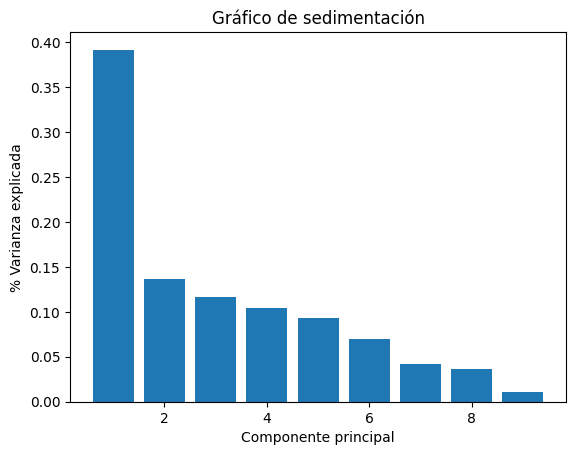

In [7]:
# Creamos un DataFrame con la varianza explicada por cada componente principal.
df_varianza = pd.DataFrame(data={'Componente': range(1, 10), 'Varianza explicada': pca.explained_variance_ratio_})

# Creamos un gráfico de barras.
plt.bar(df_varianza['Componente'], df_varianza['Varianza explicada'])

# Añadimos etiquetas y título al gráfico.
plt.xlabel('Componente principal')
plt.ylabel('% Varianza explicada')
plt.title('Gráfico de sedimentación')

# Mostramos el gráfico.
plt.show()

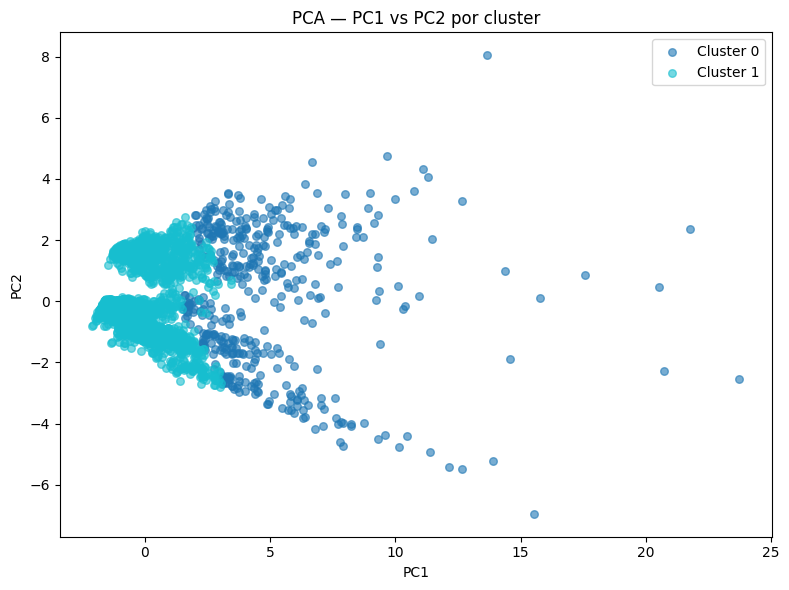

In [8]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

clusters = np.unique(cluster_labels)
colors = cm.tab10(np.linspace(0, 1, len(clusters)))

fig, ax = plt.subplots(figsize=(8, 6))
for cluster, color in zip(clusters, colors):
    mask = cluster_labels == cluster
    ax.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
               label=f'Cluster {cluster}', alpha=0.6, s=30, color=color)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA — PC1 vs PC2 por cluster')
ax.legend()
plt.tight_layout()
plt.show()

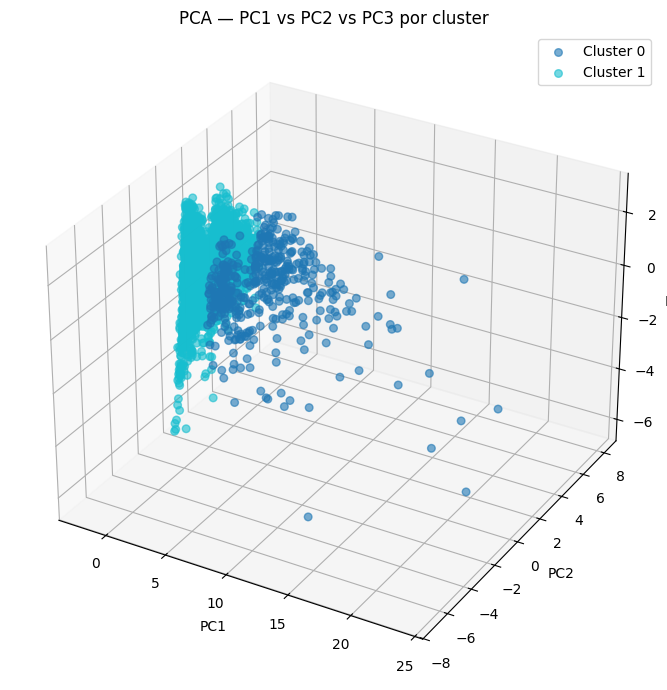

In [9]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for cluster, color in zip(clusters, colors):
    mask = cluster_labels == cluster
    ax.scatter(df_pca.loc[mask, 'PC1'],
               df_pca.loc[mask, 'PC2'],
               df_pca.loc[mask, 'PC3'],
               label=f'Cluster {cluster}', alpha=0.6, s=30, color=color)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('PCA — PC1 vs PC2 vs PC3 por cluster')
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
import numpy as np
unique, counts = np.unique(cluster_labels, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(0): np.int64(442), np.int64(1): np.int64(5024)}


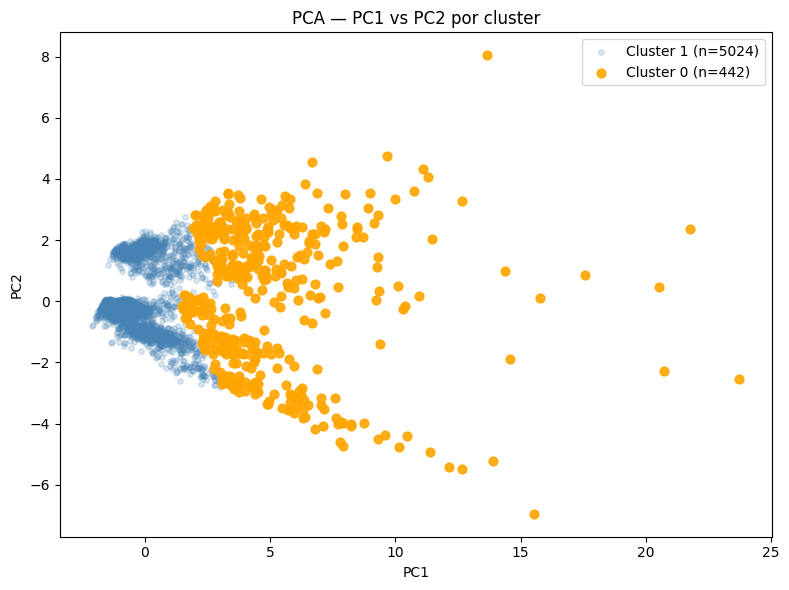

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

config = {
    1: {'color': 'steelblue', 'alpha': 0.2, 's': 15},   # grande, muy transparente
    0: {'color': 'orange',    'alpha': 0.9, 's': 40},   # pequeño, opaco y más grande
}

# Dibujar primero el grande, después el pequeño encima
for cluster in [1, 0]:
    mask = cluster_labels == cluster
    ax.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
               label=f'Cluster {cluster} (n={mask.sum()})',
               **config[cluster])

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA — PC1 vs PC2 por cluster')
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
import pandas as pd
from sklearn.decomposition import PCA

# Asumo que ya tienes tu matriz 'X' preparada y estandarizada.
# pca = PCA()
# pca.fit(X)

# 1. Calculamos dinámicamente la cantidad de componentes
num_componentes = len(pca.explained_variance_)
rango_componentes = range(1, num_componentes + 1)

# 2. DataFrame de Autovectores (Componentes Principales)
# pca.components_ contiene los autovectores.
# Filas = Componentes Principales, Columnas = Variables originales de tu dataset X
df_autovectores = pd.DataFrame(
    data=pca.components_,
    index=[f'Componente_{i}' for i in rango_componentes],
    columns=[f'Variable_{i}' for i in range(1, pca.components_.shape[1] + 1)]
    # Nota: Si tienes los nombres reales de las columnas de X, puedes reemplazarlos aquí arriba.
)

# 3. DataFrame de Varianza (Autovalores) integrando tu idea
df_varianza = pd.DataFrame(data={
    'Componente': rango_componentes,
    'Varianza (Autovalor)': pca.explained_variance_,
    'Varianza_Explicada (%)': pca.explained_variance_ratio_ * 100
})

# Mostramos los resultados
print("--- Autovectores (Componentes Principales) ---")
display(df_autovectores) # Usamos display() si estás en Jupyter Notebook, si no usa print()

print("\n--- Análisis de Varianza ---")
display(df_varianza)

--- Autovectores (Componentes Principales) ---


,Variable_1,Variable_2,Variable_3,Variable_4,Variable_5,Variable_6,Variable_7,Variable_8,Variable_9
Componente_1,0.068344,0.382053,0.352061,0.481394,0.455479,0.184237,0.378824,0.321233,-0.074662
Componente_2,-0.066367,0.146016,-0.362436,-0.175418,-0.190184,0.734001,0.437043,-0.189666,-0.101174
Componente_3,0.713630,0.059891,-0.067710,-0.085739,-0.106301,-0.033367,-0.098057,0.110803,-0.664006
Componente_4,0.661494,-0.053322,0.037492,-0.057808,-0.068870,0.147005,0.053285,0.086042,0.719888
Componente_5,-0.149329,-0.457779,0.451472,-0.228490,-0.278202,0.287713,0.039739,0.583959,-0.096657
Componente_6,-0.139714,0.511526,-0.422022,-0.162764,-0.204698,-0.183086,-0.080421,0.646162,0.121706
Componente_7,0.035031,-0.076111,0.056964,-0.128455,-0.250701,-0.535305,0.787571,-0.057152,-0.017245
Componente_8,-0.031843,0.583245,0.585302,-0.195278,-0.418840,0.033067,-0.147168,-0.281679,0.024034
Componente_9,-0.004797,-0.095375,-0.104645,0.770364,-0.618668,0.025102,-0.055307,0.003657,0.003999



--- Análisis de Varianza ---


,Componente,Varianza (Autovalor),Varianza_Explicada (%)
0,1,3.525668,39.166922
1,2,1.225456,13.613691
2,3,1.051570,11.681971
3,4,0.939722,10.439448
4,5,0.834594,9.271566
5,6,0.623919,6.931161
6,7,0.378249,4.202003
7,8,0.328629,3.650764
8,9,0.093840,1.042474
